In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
%pip install kagglehub
import kagglehub
anaghachoudhari_pcos_detection_using_ultrasound_images_path = kagglehub.dataset_download('anaghachoudhari/pcos-detection-using-ultrasound-images')

print('Data source import complete.')


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


In [3]:
import os

anaghachoudhari_pcos_detection_using_ultrasound_images_path = kagglehub.dataset_download('anaghachoudhari/pcos-detection-using-ultrasound-images')
directory = os.path.join(anaghachoudhari_pcos_detection_using_ultrasound_images_path, 'data', 'train')

In [1]:
%pip install tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
import cv2
import numpy as np
import os
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


ModuleNotFoundError: No module named 'cv2'

In [ ]:
%pip install tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
import cv2
import numpy as np
import os
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


ModuleNotFoundError: No module named 'cv2'

In [ ]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="binary",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=24,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=True,
    crop_to_aspect_ratio=False,
)

NameError: name 'tf' is not defined

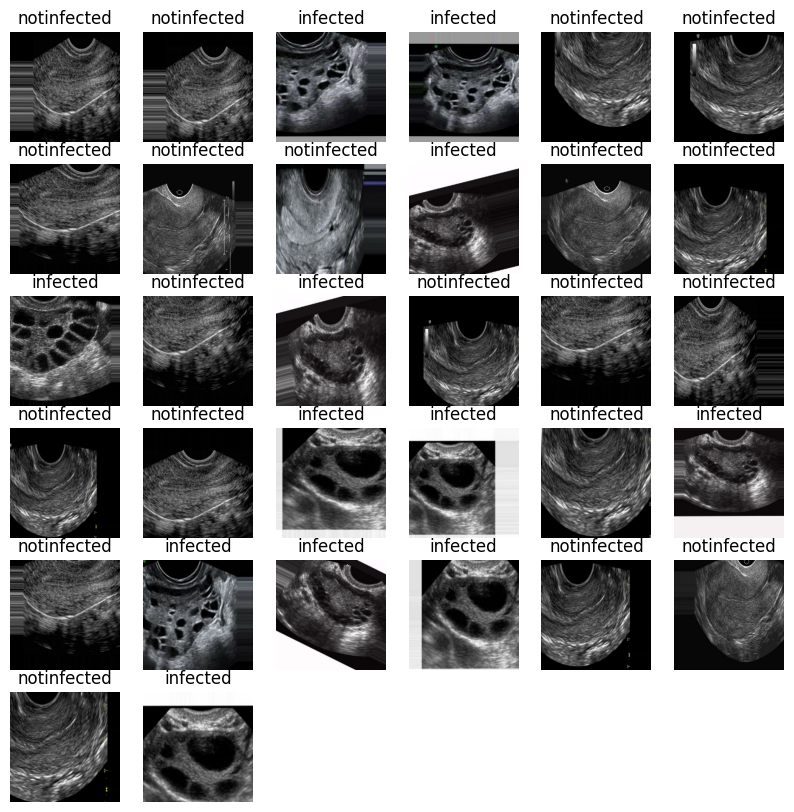

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
class_names = train_ds.class_names
for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

Augumentation


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create generator
datagen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2,
                             zoom_range = 0.2,
                             horizontal_flip = True,
                             vertical_flip=True,
                             rotation_range=30,
                             validation_split=0.3,
                             fill_mode='nearest'
                             )
# prepare an iterators for each dataset
train_it = datagen.flow_from_directory( directory,
                                       class_mode='categorical',
                                       classes=['infected', 'notinfected'],
                                       target_size=(224, 224),
                                       batch_size=100,
                                       subset='training',
                                       seed=24)
# prepare an iterators for each dataset
val_it = datagen.flow_from_directory( directory,
                                       class_mode='categorical',
                                       classes=['infected', 'notinfected'],
                                       target_size=(224, 224),
                                       batch_size=100,
                                       subset='validation',
                                       seed=24)

Found 1348 images belonging to 2 classes.
Found 576 images belonging to 2 classes.


In [ ]:
batchX, batchy = train_it.__next__()
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchy.shape, batchy.min(), batchy.max()))
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Batch shape=(100, 2), min=0.000, max=1.000
Batch shape=(100, 224, 224, 3), min=0.000, max=1.000


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import Sequential

# Model 1

In [ ]:
model1 = Sequential()
model1.add(Conv2D(10, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model1.add(MaxPooling2D(pool_size=(4,4)))
# REPEAT CONV AND POOLING layer 3 TIMES
model1.add(Conv2D(12, (5,5),padding='valid',activation='relu'))
model1.add(MaxPooling2D(pool_size=(4,4)))
#model1.add(Conv2D(128, (5,5),padding='valid',activation='relu'))
# model1.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
# model1.add(MaxPooling2D(pool_size=(4,4)))
model1.add(Flatten())
#model1.add(Dense(128,activation='relu'))
#model1.add(Dense(64,activation='relu'))
model1.add(Dense(2,activation='softmax'))

C:\Users\sampa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 10)   │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 51, 51, 12)     │         3,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         3,458 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,230 (28.24 KB)

 Trainable params: 7,230 (28.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model1.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model1.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

C:\Users\sampa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 0.7344 - loss: 0.5943 - val_accuracy: 0.8490 - val_loss: 0.4133
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8806 - loss: 0.3186 - val_accuracy: 0.8906 - val_loss: 0.2638
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9243 - loss: 0.1986 - val_accuracy: 0.9549 - val_loss: 0.1485
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.9518 - loss: 0.1376 - val_accuracy: 0.9705 - val_loss: 0.1064
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 76s 5s/step - accuracy: 0.9800 - loss: 0.0797 - val_accuracy: 0.9740 - val_loss: 0.0755


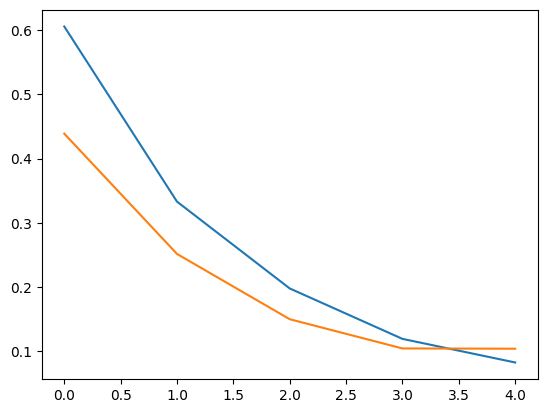

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 2

final model

In [ ]:
model2 = Sequential()
model2.add(Conv2D(12, (6,6),padding='valid',activation='relu',input_shape=(224,224,3)))
model2.add(MaxPooling2D(pool_size=(6,6)))
model2.add(Conv2D(15, (5,5),padding='valid',activation='relu'))
model2.add(MaxPooling2D(pool_size=(5,5)))
model2.add(Conv2D(10, (3,3),padding='valid',activation='relu'))
# model2.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model2.add(MaxPooling2D(pool_size=(3,3)))
model2.add(Flatten())
#model2.add(Dense(128,activation='relu'))
#model2.add(Dense(64,activation='relu'))
model2.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model2.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model2.fit(
  train_it,
  validation_data=val_it,
  epochs=8)

Epoch 1/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 94s 7s/step - accuracy: 0.5977 - loss: 0.6590 - val_accuracy: 0.8490 - val_loss: 0.5489
Epoch 2/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 138s 6s/step - accuracy: 0.8330 - loss: 0.5063 - val_accuracy: 0.9184 - val_loss: 0.3299
Epoch 3/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 0.9184 - loss: 0.2924 - val_accuracy: 0.9531 - val_loss: 0.1691
Epoch 4/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.9597 - loss: 0.1553 - val_accuracy: 0.9670 - val_loss: 0.1142
Epoch 5/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.9611 - loss: 0.1082 - val_accuracy: 0.9844 - val_loss: 0.0572
Epoch 6/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.9849 - loss: 0.0649 - val_accuracy: 0.9965 - val_loss: 0.0365
Epoch 7/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.9819 - loss: 0.0559 - val_accuracy: 0.9913 - val_loss: 0.0409
Epoch 8/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.9901 - loss: 0.0445 - val_accuracy: 0.9722 - val_loss: 0.0707

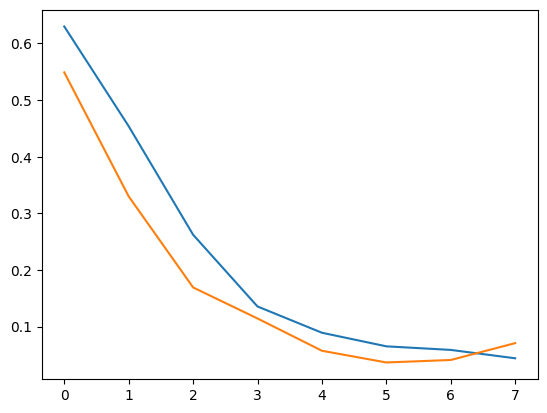

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 3


In [ ]:
model3 = Sequential()
model3.add(Conv2D(10, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model3.add(MaxPooling2D(pool_size=(4,4)))
model3.add(Conv2D(12, (5,5),padding='valid',activation='relu'))
model3.add(MaxPooling2D(pool_size=(4,4)))
model3.add(Conv2D(5, (3,3),padding='valid',activation='relu'))
# model3.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model3.add(MaxPooling2D(pool_size=(3,3)))
model3.add(Flatten())
#model3.add(Dense(128,activation='relu'))
#model3.add(Dense(64,activation='relu'))
model3.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model3.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model3.fit(
  train_it,
  validation_data=val_it,
  epochs=6)

Epoch 1/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 85s 6s/step - accuracy: 0.5841 - loss: 0.6803 - val_accuracy: 0.6076 - val_loss: 0.6566
Epoch 2/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.6339 - loss: 0.6497 - val_accuracy: 0.7778 - val_loss: 0.6145
Epoch 3/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.7424 - loss: 0.6050 - val_accuracy: 0.8247 - val_loss: 0.5166
Epoch 4/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 85s 6s/step - accuracy: 0.8127 - loss: 0.4965 - val_accuracy: 0.8594 - val_loss: 0.3809
Epoch 5/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.8741 - loss: 0.3555 - val_accuracy: 0.9271 - val_loss: 0.2695
Epoch 6/6
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.9123 - loss: 0.2537 - val_accuracy: 0.9531 - val_loss: 0.1772


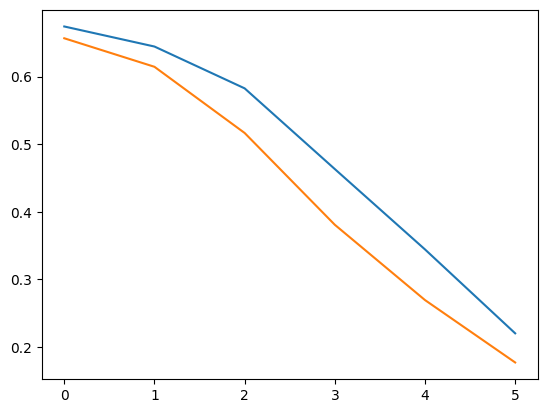

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 4

In [ ]:
model4 = Sequential()
model4.add(Conv2D(12, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model4.add(MaxPooling2D(pool_size=(4,4)))
model4.add(Conv2D(10, (5,5),padding='valid',activation='relu'))
model4.add(MaxPooling2D(pool_size=(4,4)))
model4.add(Conv2D(8, (3,3),padding='valid',activation='relu'))
# model4.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model4.add(MaxPooling2D(pool_size=(3,3)))
model4.add(Flatten())
#model4.add(Dense(128,activation='relu'))
#model4.add(Dense(64,activation='relu'))
model4.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model4.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model4.fit(
  train_it,
  validation_data=val_it,
  epochs=10)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 86s 6s/step - accuracy: 0.6257 - loss: 0.6590 - val_accuracy: 0.7240 - val_loss: 0.6212
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.7124 - loss: 0.6048 - val_accuracy: 0.7396 - val_loss: 0.5456
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.7216 - loss: 0.5437 - val_accuracy: 0.7812 - val_loss: 0.4814
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.7877 - loss: 0.4727 - val_accuracy: 0.8403 - val_loss: 0.4080
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 0.8084 - loss: 0.4455 - val_accuracy: 0.8455 - val_loss: 0.3724
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.8630 - loss: 0.3542 - val_accuracy: 0.8698 - val_loss: 0.3402
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.8810 - loss: 0.3157 - val_accuracy: 0.9323 - val_loss: 0.2468
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.9165 - loss: 0.2487 - val_accuracy: 0.9531 - val_loss

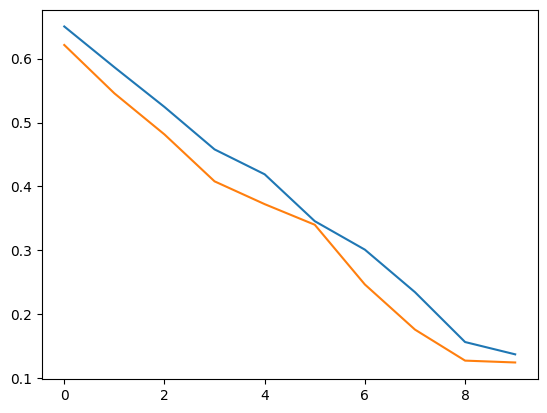

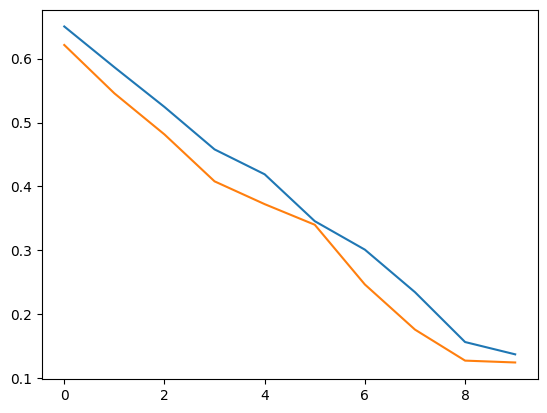

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 5

In [ ]:
model5 = Sequential()
model5.add(Conv2D(15, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model5.add(MaxPooling2D(pool_size=(5,5)))
model5.add(Conv2D(12, (4,4),padding='valid',activation='relu'))
model5.add(MaxPooling2D(pool_size=(4,4)))
model5.add(Conv2D(8, (3,3),padding='valid',activation='relu'))
# model5.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model5.add(MaxPooling2D(pool_size=(3,3)))
model5.add(Flatten())
#model5.add(Dense(128,activation='relu'))
#model5.add(Dense(64,activation='relu'))
model5.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model5.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model5.fit(
  train_it,
  validation_data=val_it,
  epochs=7)

Epoch 1/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.6897 - loss: 0.6411 - val_accuracy: 0.7674 - val_loss: 0.5458
Epoch 2/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.7579 - loss: 0.5396 - val_accuracy: 0.8351 - val_loss: 0.4181
Epoch 3/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.8419 - loss: 0.3922 - val_accuracy: 0.8924 - val_loss: 0.3077
Epoch 4/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.9079 - loss: 0.2572 - val_accuracy: 0.9358 - val_loss: 0.1995
Epoch 5/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 85s 6s/step - accuracy: 0.9403 - loss: 0.1770 - val_accuracy: 0.9566 - val_loss: 0.1289
Epoch 6/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.9622 - loss: 0.1080 - val_accuracy: 0.9722 - val_loss: 0.0765
Epoch 7/7
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.9787 - loss: 0.0891 - val_accuracy: 0.9809 - val_loss: 0.0706


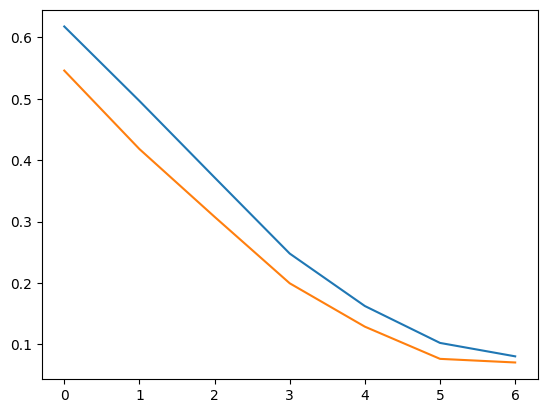

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Saving Model

In [ ]:
model2.save('model.h5')

In [ ]:
from tensorflow import keras
model = keras.models.load_model('model.h5')

In [ ]:
from keras.preprocessing.image import load_img
import os

# Assuming anaghachoudhari_pcos_detection_using_ultrasound_images_path is defined from previous cells
test_image_path = os.path.join(anaghachoudhari_pcos_detection_using_ultrasound_images_path, 'data', 'test', 'notinfected', 'img_0_1027.jpg')
image = load_img(test_image_path, target_size=(224, 224))
img = np.array(image)
img = img / 255.0
img = img.reshape(1,224,224,3)
prediction = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [ ]:
type(prediction)

numpy.ndarray

In [ ]:
print(prediction)

[[0.02780433 0.9721957 ]]


In [ ]:
l={"infected":prediction[0][0],"notinfected":prediction[0][1]}
def get_key(val):
    for key, value in l.items():
         if val == value:
             return key

    return "key doesn't exist"
#label[0][1]

In [ ]:
j=prediction.max()
get_key(j)

'notinfected'